In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os
%matplotlib inline
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv
import scipy.stats as stats
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches
from numpy.linalg import inv
import scipy.stats as stats
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import networkx as nx
from statsmodels.nonparametric.smoothers_lowess import lowess

In [ ]:

# reading the qc file 
qc_data = pd.read_excel(
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\msmetrix_data\QC_msmetrix.xlsx",
    sheet_name=0,
    header=12
)

print(qc_data.head())

   Peak    tR1    tR2     tR  m/z  \
0     1  1.864  1.949  1.906   40   
1     2  1.905  1.991  1.948   44   
2     3  1.925  2.003  1.964   81   
3     4  1.940  2.039  1.990   64   
4     5  1.960  2.090  2.025   42   

                                            ID Names  s1 S96_QC1_B1_D1_T1  \
0    0.15%  || 40                                ...                44728   
1    1.81%  || 44                                ...               354392   
2    0.14%  || 81   69  169  119                 ...                75703   
3    0.80%  || 64   48   61   66   96   37  131  ...               238856   
4    0.82%  || 42  41  40  39  38  50            ...               207592   

   s2 S96_QC2_B1_D1_T1  s3 S96_QC3_B1_D1_T1  s4 S96_QC4_B1_D1_T1  ...  \
0                46928                46096                44488  ...   
1               461936               609704                92652  ...   
2                27041                69053                62942  ...   
3               296333

In [ ]:
# metadata columns we exclud 'ID Names' since we dont need it
metadata_cols = ['Peak', 'tR1', 'tR2', 'tR', 'm/z']

# Select columns ending with T1 beacuse T1 , T2 are replicate we just selected  one of them.
t1_cols = qc_data.filter(regex="T1").columns

# Combine metadata + T1 columns
qc_data_T1 = qc_data[metadata_cols + list(t1_cols)]

print(qc_data_T1.head())


   Peak    tR1    tR2     tR  m/z  s1 S96_QC1_B1_D1_T1  s2 S96_QC2_B1_D1_T1  \
0     1  1.864  1.949  1.906   40                44728                46928   
1     2  1.905  1.991  1.948   44               354392               461936   
2     3  1.925  2.003  1.964   81                75703                27041   
3     4  1.940  2.039  1.990   64               238856               296333   
4     5  1.960  2.090  2.025   42               207592               197912   

   s3 S96_QC3_B1_D1_T1  s4 S96_QC4_B1_D1_T1  s5 S96_QC1_B1_D2_T1  ...  \
0                46096                44488                47288  ...   
1               609704                92652               326936  ...   
2                69053                62942                41856  ...   
3               363394               280169               239716  ...   
4               201184               105097               226030  ...   

   s31 S96_QC3_B1_D7_T1  s32 S96_QC4_B1_D10_T1  s33 S96_QC4_B1_D6_T1  \
0             

In [ ]:
# we got the information of qcdata to see more details
qc_data_T1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 589 entries, 0 to 588
Data columns (total 45 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Peak                   589 non-null    int64  
 1   tR1                    589 non-null    float64
 2   tR2                    589 non-null    float64
 3   tR                     589 non-null    float64
 4   m/z                    589 non-null    int64  
 5   s1 S96_QC1_B1_D1_T1    589 non-null    int64  
 6   s2 S96_QC2_B1_D1_T1    589 non-null    int64  
 7   s3 S96_QC3_B1_D1_T1    589 non-null    int64  
 8   s4 S96_QC4_B1_D1_T1    589 non-null    int64  
 9   s5 S96_QC1_B1_D2_T1    589 non-null    int64  
 10  s6 S96_QC2_B1_D2_T1    589 non-null    int64  
 11  s7 S96_QC3_B1_D2_T1    589 non-null    int64  
 12  s8 S96_QC4_B1_D2_T1    589 non-null    int64  
 13  s9 S96_QC1_B1_D3_T1    589 non-null    int64  
 14  s10 S96_QC2_B1_D3_T1   589 non-null    int64  
 15  s11 S9

In [ ]:

# getting differences between retention time beacuse we want to have just one retention time
diff_t_vs_1 = (qc_data_T1['tR'] - qc_data_T1['tR1']).abs()
diff_t_vs_2 = (qc_data_T1['tR'] - qc_data_T1['tR2']).abs()
diff_1_vs_2 = (qc_data_T1['tR1'] - qc_data_T1['tR2']).abs()
avg_t   = (qc_data_T1['tR1'] + qc_data_T1['tR2']) / 2
diff_avg_vs_t = (avg_t - qc_data['tR']).abs()

# printing the results
print("abs(tR - tR1):\n", diff_t_vs_1.describe(), "\n")
print("abs(tR - tR2):\n", diff_t_vs_2.describe(), "\n")
print("abs(tR1 - tR2):\n", diff_1_vs_2.describe(), "\n")
print("abs(avg(tR1,tR2) - tR):\n", diff_avg_vs_t.describe(), "\n")


abs(tR - tR1):
 count    589.000000
mean       0.033163
std        0.018089
min        0.015000
25%        0.021000
50%        0.027000
75%        0.039000
max        0.141000
dtype: float64 

abs(tR - tR2):
 count    589.000000
mean       0.033136
std        0.018078
min        0.015000
25%        0.021000
50%        0.027000
75%        0.038000
max        0.141000
dtype: float64 

abs(tR1 - tR2):
 count    589.000000
mean       0.066299
std        0.036161
min        0.030000
25%        0.042000
50%        0.053000
75%        0.077000
max        0.282000
dtype: float64 

abs(avg(tR1,tR2) - tR):
 count    5.890000e+02
mean     2.393888e-04
std      2.499870e-04
min      0.000000e+00
25%      0.000000e+00
50%      3.552714e-15
75%      5.000000e-04
max      5.000000e-04
dtype: float64 



In [6]:
# put tr_best instead of other tr
qc_data_T1['tR_best'] = (qc_data_T1['tR1'] + qc_data_T1['tR2']) / 2

# removing unnecessary columns
to_keep = [col for col in qc_data_T1.columns if col not in ['tR1', 'tR2', 'tR']]
cleaned_qc = qc_data_T1[to_keep]

# Confirm that 'tR_best' is included
print("tR_best column saved:", 'tR_best' in cleaned_qc.columns)

cols = cleaned_qc.columns.tolist()

# Moving 'tR_best' after 'Peak'
cols.insert(cols.index('Peak') + 1, cols.pop(cols.index('tR_best')))

# Reorder the DataFrame
cleaned_qc = cleaned_qc[cols]

# Check the result
print(cleaned_qc.head())
# Save cleaned data with tR_best
cleaned_qc.to_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\msmetrix_data\cleaned_qc.csv", index=False)
# now this cleaned_qc datafram can be used for further analysis

tR_best column saved: True
   Peak  tR_best  m/z  s1 S96_QC1_B1_D1_T1  s2 S96_QC2_B1_D1_T1  \
0     1   1.9065   40                44728                46928   
1     2   1.9480   44               354392               461936   
2     3   1.9640   81                75703                27041   
3     4   1.9895   64               238856               296333   
4     5   2.0250   42               207592               197912   

   s3 S96_QC3_B1_D1_T1  s4 S96_QC4_B1_D1_T1  s5 S96_QC1_B1_D2_T1  \
0                46096                44488                47288   
1               609704                92652               326936   
2                69053                62942                41856   
3               363394               280169               239716   
4               201184               105097               226030   

   s6 S96_QC2_B1_D2_T1  s7 S96_QC3_B1_D2_T1  ...  s31 S96_QC3_B1_D7_T1  \
0                46560                45104  ...                 45912   
1            

In [ ]:

input_path  = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\msmetrix_data\samples day1-10.xlsx"
output_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\msmetrix_data\all_real_samples_combined.xlsx"

# Reading without headers, just to find the header row
df_raw = pd.read_excel(input_path, header=None)

# getting the data columns
header_row = df_raw[df_raw.iloc[:,0].astype(str).str.strip() == "Peak"].index[0]

# Re-reading using that row as the header
potato_data = pd.read_excel(input_path, header=header_row)


metadata_cols = ['Peak', 'tR1', 'tR2', 'tR', 'm/z']
# Select columns ending with T1 since we have T1 , T2 which are replicates
t1_cols = potato_data .filter(regex="T1").columns

# Combine metadata + T1 columns
potato_data_T1 = potato_data [metadata_cols + list(t1_cols)]

#  Seeing the dataframe
print(potato_data_T1.shape)
print(potato_data_T1.columns.tolist())
print(potato_data_T1.head())



(633, 89)
['Peak', 'tR1', 'tR2', 'tR', 'm/z', 's1 S96_44_B1_D1_T1', 's3 S96_9_B1_D1_T1', 's4 S96_28_B1_D1_T1', 's5 S96_92_B1_D1_T1', 's6 S96_21_B1_D1_T1', 's7 S96_53_B1_D1_T1', 's8 S96_55_B1_D1_T1', 's17 S96_83_B1_D1_T1', 's18 S96_7_B1_D1_T1', 's20 S96_42_B1_D2_T1', 's21 S96_56_B1_D2_T1', 's22 S96_6_B1_D2_T1', 's23 S96_38_B1_D2_T1', 's24 S96_48_B1_D2_T1', 's25 S96_76_B1_D2_T1', 's26 S96_10_B1_D2_T1', 's36 S96_79_B1_D2_T1', 's37 S96_86_B1_D2_T1', 's38 S96_87_B1_D3_T1', 's39 S96_16_B1_D3_T1', 's40 S96_81_B1_D3_T1', 's42 S96_50_B1_D3_T1', 's44 S96_68_B1_D3_T1', 's45 S96_66_B1_D3_T1', 's51 S96_60_B1_D3_T1', 's53 S96_5_B1_D3_T1', 's55 S96_37_B1_D4_T1', 's57 S96_4_B1_D4_T1', 's58 S96_57_B1_D4_T1', 's59 S96_18_B1_D4_T1', 's60 S96_43_B1_D4_T1', 's61 S96_8_B1_D4_T1', 's62 S96_75_B1_D4_T1', 's63 S96_51_B1_D4_T1', 's64 S96_94_B1_D4_T1', 's68 S96_61_B1_D4_T1', 's75 S96_35_B1_D5_T1', 's76 S96_73_B1_D5_T1', 's77 S96_71_B1_D5_T1', 's78 S96_12_B1_D5_T1', 's79 S96_30_B1_D5_T1', 's80 S96_1_B1_D5_T1', 's

In [ ]:
# since top of the dataframe are some information excluding the data we exclude those parts
selected_data = potato_data_T1.iloc[:, :101]
selected_data

,Peak,tR1,tR2,tR,m/z,s1 S96_44_B1_D1_T1,s3 S96_9_B1_D1_T1,s4 S96_28_B1_D1_T1,s5 S96_92_B1_D1_T1,s6 S96_21_B1_D1_T1,...,s151 S96_29_B1_D9_T1,s152 S96_17_B1_D9_T1,s153 S96_20_B1_D9_T1,s154 S96_13_B1_D9_T1,s155 S96_23_B1_D9_T1,s156 S96_62_B1_D9_T1,s157 S96_3_B1_D9_T1,s158 S96_27_B1_D9_T1,s159 S96_72_B1_D9_T1,s169 S96_39_B1_D3_T1
0,1,1.863,1.948,1.905,40,10596,16056,19568,14816,21952,...,30640,10596,10596,10596,26152,27680,28728,10596,28696,14504
1,2,1.915,2.010,1.962,44,65017,59978,73618,773172,64221,...,642077,361022,63779,86459,66469,286899,64753,61149,66203,59615
2,3,1.946,2.003,1.974,81,25722,24105,25044,19636,21617,...,118664,48202,57061,70136,45617,26179,65044,39207,83865,14288
3,4,1.946,2.045,1.996,42,3396147,1910915,2419738,4436911,1439246,...,1022562,1551257,1690930,1212485,1009947,861171,1203187,577635,1309274,6064894
4,5,1.983,2.100,2.041,41,3040149,1060080,1516523,4284595,1430717,...,503620,714507,831567,784458,465771,396239,424572,378953,403766,5332368
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
628,629,23.161,23.365,23.263,205,6363,4376,3712,5439,4796,...,10344,88492,12615,13646,14097,12014,33264,13250,14531,5967
629,630,23.207,23.421,23.314,57,64953,4750,94036,103763,105188,...,26342,21218,22927,21786,21836,21331,27436,23608,25700,22734
630,631,23.302,23.440,23.371,191,40222,6976,40658,50771,82752,...,24883,27432,23381,22783,20477,20427,20615,23193,26466,11857
631,632,23.382,23.442,23.412,220,65225,9759,48693,47673,153082,...,73559,40220,38625,31833,33360,28541,37976,43672,41365,15401


In [ ]:
#  checking to see if we have missing value or not
selected_data.isnull().sum()

Peak                    0
tR1                     0
tR2                     0
tR                      0
m/z                     0
                       ..
s156 S96_62_B1_D9_T1    0
s157 S96_3_B1_D9_T1     0
s158 S96_27_B1_D9_T1    0
s159 S96_72_B1_D9_T1    0
s169 S96_39_B1_D3_T1    0
Length: 89, dtype: int64

In [ ]:

# getting the differences to find the realation between retention times
diff_t_vs_1 = (selected_data['tR'] - selected_data['tR1']).abs()
diff_t_vs_2 = (selected_data['tR'] - selected_data['tR2']).abs()
diff_1_vs_2 = (selected_data['tR1'] - selected_data['tR2']).abs()
avg_t   = (selected_data['tR1'] + selected_data['tR2']) / 2
diff_avg_vs_t = (avg_t - selected_data['tR']).abs()

# printing to see the results
print("abs(tR - tR1):\n", diff_t_vs_1.describe(), "\n")
print("abs(tR - tR2):\n", diff_t_vs_2.describe(), "\n")
print("abs(tR1 - tR2):\n", diff_1_vs_2.describe(), "\n")
print("abs(avg(tR1,tR2) - tR):\n", diff_avg_vs_t.describe(), "\n")


abs(tR - tR1):
 count    633.000000
mean       0.050104
std        0.035097
min        0.015000
25%        0.028000
50%        0.041000
75%        0.061000
max        0.369000
dtype: float64 

abs(tR - tR2):
 count    633.000000
mean       0.050137
std        0.035105
min        0.015000
25%        0.027000
50%        0.041000
75%        0.061000
max        0.369000
dtype: float64 

abs(tR1 - tR2):
 count    633.000000
mean       0.100242
std        0.070199
min        0.030000
25%        0.055000
50%        0.081000
75%        0.122000
max        0.738000
dtype: float64 

abs(avg(tR1,tR2) - tR):
 count    6.330000e+02
mean     2.330174e-04
std      2.496198e-04
min      0.000000e+00
25%      0.000000e+00
50%      3.552714e-15
75%      5.000000e-04
max      5.000000e-04
dtype: float64 




the two measurements are consistent with each other, and tR serves as a reliable midpoint that smooths out the small differences between them.


In [ ]:
# Rename tR to tR_best 
selected_data = selected_data.rename(columns={'tR': 'tR_best'})
# Select only columns we need them
columns_to_keep = ['Peak', 'tR_best', 'm/z'] + [c for c in selected_data.columns if c.startswith('s')]
selected_with_trbest = selected_data[columns_to_keep].copy()

print("Selected data shape:", selected_with_trbest.shape)
display(selected_with_trbest.head(10))



Selected data shape: (633, 87)


,Peak,tR_best,m/z,s1 S96_44_B1_D1_T1,s3 S96_9_B1_D1_T1,s4 S96_28_B1_D1_T1,s5 S96_92_B1_D1_T1,s6 S96_21_B1_D1_T1,s7 S96_53_B1_D1_T1,s8 S96_55_B1_D1_T1,...,s151 S96_29_B1_D9_T1,s152 S96_17_B1_D9_T1,s153 S96_20_B1_D9_T1,s154 S96_13_B1_D9_T1,s155 S96_23_B1_D9_T1,s156 S96_62_B1_D9_T1,s157 S96_3_B1_D9_T1,s158 S96_27_B1_D9_T1,s159 S96_72_B1_D9_T1,s169 S96_39_B1_D3_T1
0,1,1.905,40,10596,16056,19568,14816,21952,15944,18576,...,30640,10596,10596,10596,26152,27680,28728,10596,28696,14504
1,2,1.962,44,65017,59978,73618,773172,64221,69786,60623,...,642077,361022,63779,86459,66469,286899,64753,61149,66203,59615
2,3,1.974,81,25722,24105,25044,19636,21617,24875,22825,...,118664,48202,57061,70136,45617,26179,65044,39207,83865,14288
3,4,1.996,42,3396147,1910915,2419738,4436911,1439246,3454617,2840480,...,1022562,1551257,1690930,1212485,1009947,861171,1203187,577635,1309274,6064894
4,5,2.041,41,3040149,1060080,1516523,4284595,1430717,4093964,1280799,...,503620,714507,831567,784458,465771,396239,424572,378953,403766,5332368
5,6,2.106,69,7269,12258,7309,6591,12897,18335,10268,...,35088,3062,1718,37412,16117,5234,1718,5492,14959,13620
6,7,2.167,45,24743814,21578421,22220492,21980744,21669961,21044739,20051616,...,5855232,7676292,8569464,9117764,5323974,3771887,5033398,4417086,4151476,22367779
7,8,2.202,68,164292,326813,226085,174190,329724,143339,191457,...,109714,110859,124049,89435,74300,65768,146835,120532,123642,144643
8,9,2.250,79,1340328,2041408,2430833,1643480,1728070,2081927,3633268,...,326739,714159,658699,307979,360582,303327,377913,366624,496814,1243359
9,10,2.302,101,22195,28205,34142,27351,30366,30230,41013,...,5203,5990,10991,3183,5982,4262,9801,5543,12280,23546


# Peak detection for qc data(compound identification)

In [ ]:
# Define known alkanes with accurate retention time (tR) as we know these retention times
alkanes = [
    {'Compound': 'Octane',      'tR': 5.34},
    {'Compound': 'Decane',      'tR': 10.154},
    {'Compound': 'Dodecane',    'tR': 13.626},
    {'Compound': 'Tetradecane', 'tR': 16.388},
    {'Compound': 'Pentadecane', 'tR': 17.62},
    {'Compound': 'Octadecane',  'tR': 20.906},
    {'Compound': 'Eicosane',    'tR': 22.825},
]

# Converting to DataFrame
alkane_df = pd.DataFrame(alkanes)

# Set tighter tolerance for GC-MS matching
tr_tol = 0.2  # try 0.2 min window
mz_tol = 2    # use ±2 m/z

# Matching function
def match_alkane(row):
    for _, alk in alkane_df.iterrows():
        if abs(row['tR_best'] - alk['tR']) <= tr_tol:
            return alk['Compound']
    return 'Unknown'

# Apply cleaned qc
cleaned_qc['Matched_Compound'] = cleaned_qc.apply(match_alkane, axis=1)

# Show matches 
matched = cleaned_qc[cleaned_qc['Matched_Compound'] != 'Unknown']
display(matched[['Peak', 'tR_best', 'm/z', 'Matched_Compound']])


,Peak,tR_best,m/z,Matched_Compound
67,68,5.1565,133,Octane
68,69,5.1760,149,Octane
69,70,5.3015,85,Octane
70,71,5.3270,43,Octane
71,72,5.4685,97,Octane
...,...,...,...,...
571,572,22.9020,85,Eicosane
572,573,22.9315,208,Eicosane
573,574,22.9695,57,Eicosane
574,575,22.9960,73,Eicosane


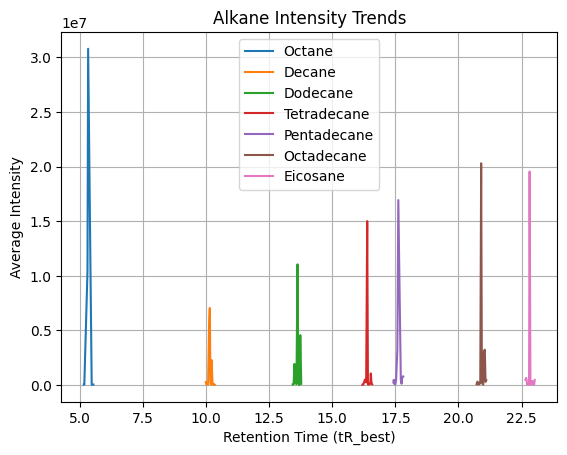

In [ ]:
# Select only numeric intensity columns 
intensity_cols = cleaned_qc.select_dtypes(include='number').columns.difference(['Peak', 'tR_best', 'm/z'])

# Plot mean intensity for each matched compound
for compound in cleaned_qc['Matched_Compound'].unique():
    if compound != 'Unknown':
        subset = cleaned_qc[cleaned_qc['Matched_Compound'] == compound]
        avg_intensity = subset[intensity_cols].mean(axis=1)
        plt.plot(subset['tR_best'], avg_intensity, label=compound)

plt.xlabel('Retention Time (tR_best)')
plt.ylabel('Average Intensity')
plt.title('Alkane Intensity Trends')
plt.legend()
plt.grid(True)
plt.show() 

# QC Drift Correction 

In [ ]:



alpha = 0.05  # p-value threshold for drift
frac = 0.2    # LOESS smoothing parameter

file_master = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\files\project file\GCMS Steamed 96 set 2024- Mastertable(Sheet1).csv"
file_qc = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\msmetrix_data\cleaned_qc.csv"
master_table=pd.read_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\files\project file\GCMS Steamed 96 set 2024- Mastertable(Sheet1).csv")
metadata_cols = ['Peak', 'tR_best', 'm/z']  
intensity_cols = [c for c in cleaned_qc.columns if c not in metadata_cols]

# Clean sample names
rename_map = {col: col.split()[-1] for col in intensity_cols}
cleaned_qc.rename(columns=rename_map, inplace=True)
intensity_cols = [rename_map[c] for c in intensity_cols]

# Reshape to long format
long_qc = cleaned_qc.melt(
    id_vars=metadata_cols,
    value_vars=intensity_cols,
    var_name="Filename",
    value_name="Intensity"
)
merged = master_table.merge(long_qc, on="Filename", how="inner")
# Ensure numeric intensity
merged['Intensity'] = pd.to_numeric(merged['Intensity'], errors='coerce')
merged = merged.dropna(subset=['Intensity', 'Injection_order'])

corrected = merged.copy()
corrected['Intensity'] = corrected['Intensity'].astype(float)

results = []
for peak in merged['Peak'].unique():
    subset = merged[merged['Peak'] == peak].dropna(subset=['Intensity', 'Injection_order'])
    y = subset['Intensity'].values
    if len(y) < 2 or len(np.unique(y)) == 1:
        continue  # Skip if insufficient variation
    X = sm.add_constant(subset['Injection_order'].values)
    model = sm.OLS(y, X).fit()
    slope, pvalue = model.params[1], model.pvalues[1]

    if pvalue < alpha:
        loess_fit = lowess(y, subset['Injection_order'], frac=frac, return_sorted=False)
        corrected.loc[corrected['Peak'] == peak, 'Intensity'] = y - (loess_fit - loess_fit[0])
        corrected_flag = True
    else:
        corrected_flag = False

    results.append({
        'Peak': peak,
        'Slope': slope,
        'p-value': pvalue,
        'Corrected': corrected_flag
    })

drift_summary = pd.DataFrame(results).sort_values('p-value')

print(drift_summary)
print(drift_summary['Corrected'].value_counts())
strong_drift = drift_summary[drift_summary['p-value'] < 0.01]
print(strong_drift.head())


     Peak        Slope       p-value  Corrected
28     29  4888.972337  1.509369e-08       True
238   239  -596.917510  2.251183e-07       True
133   134  -141.530596  3.497697e-07       True
316   317 -2516.456725  5.459631e-07       True
450   451  -342.227681  1.345450e-06       True
..    ...          ...           ...        ...
112   113    -0.149629  9.789006e-01      False
160   161     1.494835  9.815615e-01      False
258   259     3.324161  9.820027e-01      False
451   452   233.162859  9.902422e-01      False
83     84     0.010302  9.971881e-01      False

[589 rows x 4 columns]
Corrected
True     295
False    294
Name: count, dtype: int64
     Peak        Slope       p-value  Corrected
28     29  4888.972337  1.509369e-08       True
238   239  -596.917510  2.251183e-07       True
133   134  -141.530596  3.497697e-07       True
316   317 -2516.456725  5.459631e-07       True
450   451  -342.227681  1.345450e-06       True


589 total peaks were analyzed.

295 peaks (≈50%) showed significant drift (Corrected = True).

294 peaks had no significant drift (Corrected = False).

If p-value < 0.05 → The drift is statistically significant, and it must be corrected.

If p-value > 0.05 → The drift is weak (not statistically significant), and it can be ignored.

Next steps after this:

We can apply drift correction only to the compounds where the drift is significant.

Optionally, we can use non-linear methods (e.g., LOESS smoothing) if the drift is not linear.

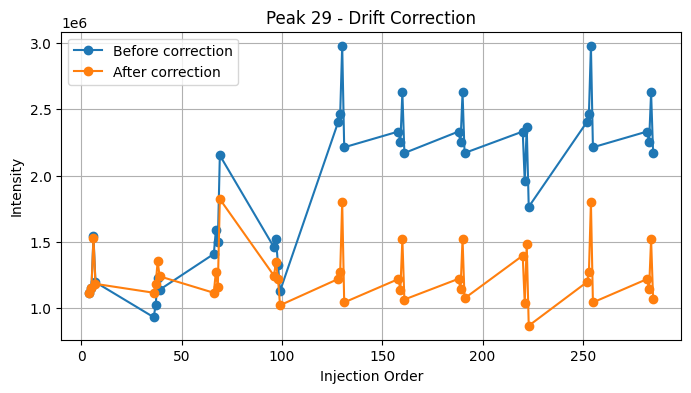

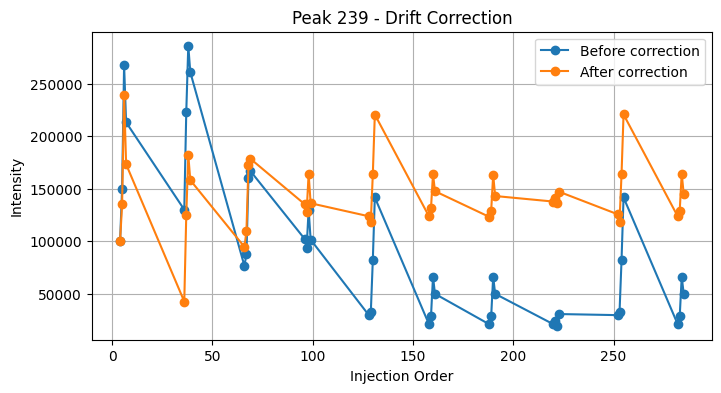

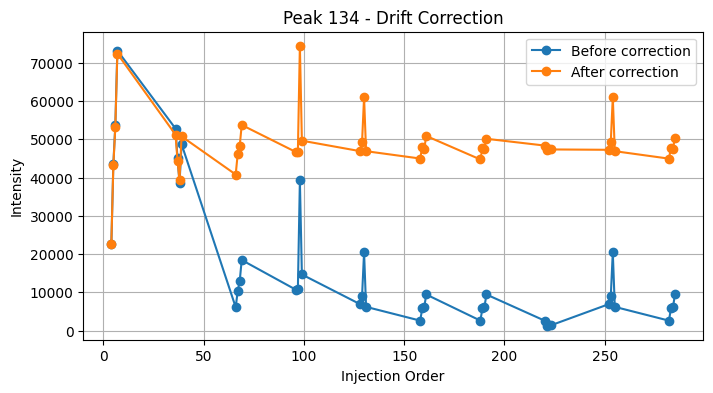

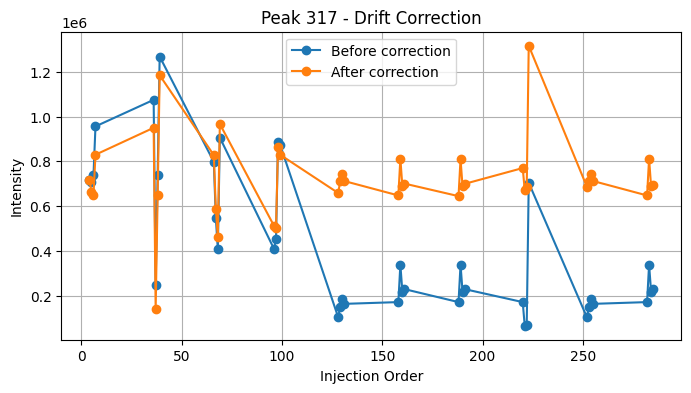

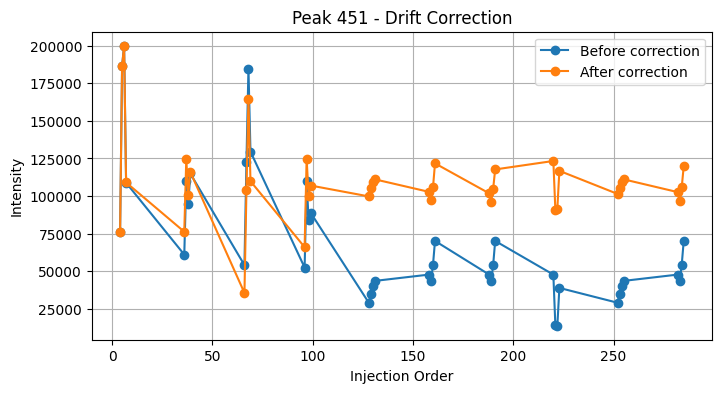

In [15]:

# Pick top 5 most corrected peaks
top_peaks = drift_summary[drift_summary['Corrected']].nsmallest(5, 'p-value')['Peak']

for peak in top_peaks:
    before = merged[merged['Peak'] == peak]
    after = corrected[corrected['Peak'] == peak]
    
    plt.figure(figsize=(8,4))
    plt.plot(before['Injection_order'], before['Intensity'], 'o-', label='Before correction')
    plt.plot(after['Injection_order'], after['Intensity'], 'o-', label='After correction')
    plt.title(f"Peak {peak} - Drift Correction")
    plt.xlabel("Injection Order")
    plt.ylabel("Intensity")
    plt.legend()
    plt.grid(True)
    plt.show()


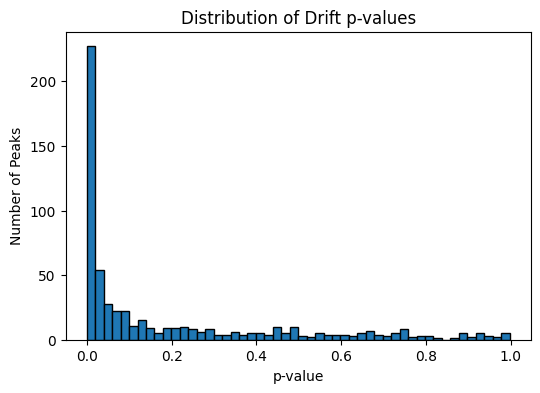

In [16]:
plt.figure(figsize=(6,4))
plt.hist(drift_summary['p-value'], bins=50, edgecolor='black')
plt.title("Distribution of Drift p-values")
plt.xlabel("p-value")
plt.ylabel("Number of Peaks")
plt.show()


A large cluster of peaks has very low p‑values (<0.05), meaning strong, statistically significant drift.

A long tail of peaks shows higher p‑values (0.2–1.0), meaning little to no drift.

# QC preparation

In [17]:

from sklearn.impute import KNNImputer

# === 1. Reshape corrected data to wide format ===
wide_corrected = corrected.pivot_table(
    index=['Filename', 'Injection_order'],
    columns='Peak',
    values='Intensity',
    aggfunc='mean'
).reset_index()

# Separate metadata & features
metadata_cols = ['Filename', 'Injection_order']
feature_cols = [c for c in wide_corrected.columns if c not in metadata_cols]
intensities = wide_corrected[feature_cols].copy()

# === 2. QC-based feature filtering (RSD < 0.5) ===
qc_mask = wide_corrected['Filename'].str.contains("QC", case=False, na=False)
qc_data = intensities[qc_mask]
rsd = qc_data.std(axis=0) / qc_data.mean(axis=0)
kept_features = rsd[rsd < 0.5].index
if len(kept_features) == 0:
    print("No features passed RSD filter. Using all features.")
    kept_features = intensities.columns
intensities = intensities[kept_features]
print(f"Features kept after RSD filtering: {len(kept_features)}")

# === 3. Probabilistic Quotient Normalization (PQN) ===
qc_median = qc_data[kept_features].median(axis=0).replace(0, np.nan).fillna(qc_data[kept_features].mean())
quotients = intensities.div(qc_median, axis=1)
pqn_factors = quotients.median(axis=1).replace(0, np.nan).fillna(1)
intensities = intensities.div(pqn_factors, axis=0)

# === 4. Log transform (shifted to avoid negatives) ===
min_val = intensities.min().min()
shift = abs(min_val) + 1 if min_val <= 0 else 0
intensities = np.log1p(intensities + shift)

# === 5. KNN Imputation (if missing values exist) ===
imputer = KNNImputer(n_neighbors=3)
intensities_imputed = imputer.fit_transform(intensities)
intensities = pd.DataFrame(intensities_imputed, columns=kept_features, index=wide_corrected.index)

# === 6. Autoscaling (z-score) ===
scaler = StandardScaler()
intensities_scaled = scaler.fit_transform(intensities)
processed_features = pd.DataFrame(intensities_scaled, columns=kept_features, index=wide_corrected.index)

# === 7. Combine metadata + scaled features ===
processed_data = pd.concat([wide_corrected[metadata_cols], processed_features], axis=1)
print(f"Processed samples shape: {processed_data.shape}")
display(processed_data.head())

Features kept after RSD filtering: 340
Processed samples shape: (40, 342)


Peak,Filename,Injection_order,1,4,5,6,7,8,9,12,...,568,570,572,578,580,581,582,584,586,588
0,S96_QC1_B1_D10_T1,282,0.107365,-0.524310,0.452820,-0.482685,-1.664195,0.082183,0.308655,-1.713385,...,-0.656338,-0.217908,0.044222,-0.105081,-0.436539,0.501009,-0.381975,0.090013,0.338488,0.215598
1,S96_QC1_B1_D1_T1,4,4.865394,4.650650,3.248888,3.420763,4.052558,1.462640,4.061714,1.948834,...,1.544980,-2.107622,2.028303,0.217873,-3.006397,3.706853,0.527782,1.493175,0.850025,-2.642116
2,S96_QC1_B1_D2_T1,36,0.138322,-0.331371,0.302977,-1.217424,-0.169563,2.010599,0.851479,-0.051440,...,-0.709213,-0.401783,-0.391437,-1.320370,-0.786252,-0.628738,-0.370042,-0.124061,-0.923332,0.155715
3,S96_QC1_B1_D3_T1,66,0.599383,-2.262373,0.345014,-1.135652,0.120617,1.488836,1.077249,-0.315300,...,-2.203518,-0.196392,-0.217101,0.887013,-1.945445,-1.882784,-0.469089,-0.193914,-0.613282,-0.970721
4,S96_QC1_B1_D4_T1,96,-2.092215,-1.131540,-0.592032,-1.334953,0.149733,1.469488,1.164960,0.250081,...,-1.917369,-0.627972,1.553498,1.650539,1.149319,0.687719,-0.413256,-0.281676,-0.289260,-1.019506


# Check QC performance



Top 20 contributing features to PC1:
Peak
379    0.089617
523    0.089331
277    0.089213
491    0.089208
169    0.089150
388    0.089094
401    0.089052
306    0.089007
483    0.088997
470    0.088989
304    0.088983
449    0.088963
550    0.088870
520    0.088842
465    0.088820
427    0.088807
392    0.088793
367    0.088740
447    0.088735
525    0.088685
Name: PC1_Loading, dtype: float64


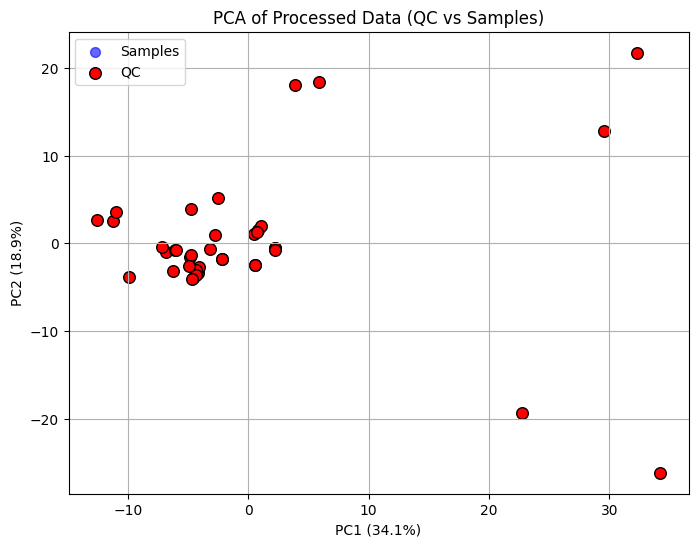

In [18]:
pca = PCA(n_components=2)
pca_scores = pca.fit_transform(processed_features)

# === 9. Feature contributions to PC1 ===
loadings = pd.Series(pca.components_[0], index=kept_features, name='PC1_Loading')
top20 = loadings.abs().sort_values(ascending=False).head(20)
print("Top 20 contributing features to PC1:")
print(top20)

# === 10. PCA Plot (QC vs Samples) ===
plt.figure(figsize=(8,6))
plt.scatter(
    pca_scores[~qc_mask,0], pca_scores[~qc_mask,1],
    c='blue', label='Samples', alpha=0.6, s=50
)
plt.scatter(
    pca_scores[qc_mask,0], pca_scores[qc_mask,1],
    c='red', label='QC', edgecolor='k', s=70
)
plt.title("PCA of Processed Data (QC vs Samples)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend()
plt.grid(True)
plt.show()

# flag/remove outlier and re‑process

In [20]:
outlier_idx = np.where((pca_scores[:,0] > 20) | (pca_scores[:,1] > 20))[0]
print(wide_corrected.iloc[outlier_idx][['Filename','Injection_order']])


Peak          Filename  Injection_order
1     S96_QC1_B1_D1_T1                4
11    S96_QC2_B1_D1_T1                5
21    S96_QC3_B1_D1_T1                6
31    S96_QC4_B1_D1_T1                7


In [21]:
from scipy.stats import spearmanr
corr, pval = spearmanr(wide_corrected['Injection_order'], pca_scores[:,0])
print(f"PC1 vs Injection order correlation: {corr:.2f} (p={pval:.4f})")


PC1 vs Injection order correlation: -0.17 (p=0.3031)


# Sample prepration

In [22]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

# === Step 1: Pivot to wide format (sample x feature) ===
wide_corrected = corrected.pivot_table(
    index=['Filename', 'Injection_order'],
    columns='Peak',
    values='Intensity',
    aggfunc='mean'
).reset_index()

metadata_cols = ['Filename', 'Injection_order']
feature_cols = [c for c in wide_corrected.columns if c not in metadata_cols]

# Use previously selected QC-stable features
intensities = wide_corrected[kept_features].copy()

# === Step 2: PQN Normalization ===
qc_mask = wide_corrected['Filename'].str.contains("QC", case=False, na=False)
qc_data = intensities[qc_mask]
qc_median = qc_data.median(axis=0).replace(0, np.nan).fillna(qc_data.mean())

quotients = intensities.div(qc_median, axis=1)
pqn_factors = quotients.median(axis=1).replace(0, np.nan).fillna(1)
intensities = intensities.div(pqn_factors, axis=0)

# === Step 3: Log-transform (shift if needed to avoid log(0)) ===
shift = abs(intensities.min().min()) + 1
intensities = np.log1p(intensities + shift)

# === Step 4: KNN Imputation (if missing values exist) ===
imputer = KNNImputer(n_neighbors=3)
intensities_imputed = imputer.fit_transform(intensities)
intensities = pd.DataFrame(intensities_imputed, columns=kept_features, index=wide_corrected.index)

# === Step 5: Autoscaling (Z-score) ===
scaler = StandardScaler()
intensities_scaled = scaler.fit_transform(intensities)
processed_features_scaled = pd.DataFrame(intensities_scaled, columns=kept_features, index=wide_corrected.index)

# === Step 6: Add metadata back ===
processed_samples = pd.concat([wide_corrected[metadata_cols], processed_features_scaled], axis=1)

print(f"Final sample matrix shape: {processed_samples.shape}")
processed_samples.head()


Final sample matrix shape: (40, 342)


Peak,Filename,Injection_order,1,4,5,6,7,8,9,12,...,568,570,572,578,580,581,582,584,586,588
0,S96_QC1_B1_D10_T1,282,0.107365,-0.524310,0.452820,-0.482685,-1.664195,0.082183,0.308655,-1.713385,...,-0.656338,-0.217908,0.044222,-0.105081,-0.436539,0.501009,-0.381975,0.090013,0.338488,0.215598
1,S96_QC1_B1_D1_T1,4,4.865394,4.650650,3.248888,3.420763,4.052558,1.462640,4.061714,1.948834,...,1.544980,-2.107622,2.028303,0.217873,-3.006397,3.706853,0.527782,1.493175,0.850025,-2.642116
2,S96_QC1_B1_D2_T1,36,0.138322,-0.331371,0.302977,-1.217424,-0.169563,2.010599,0.851479,-0.051440,...,-0.709213,-0.401783,-0.391437,-1.320370,-0.786252,-0.628738,-0.370042,-0.124061,-0.923332,0.155715
3,S96_QC1_B1_D3_T1,66,0.599383,-2.262373,0.345014,-1.135652,0.120617,1.488836,1.077249,-0.315300,...,-2.203518,-0.196392,-0.217101,0.887013,-1.945445,-1.882784,-0.469089,-0.193914,-0.613282,-0.970721
4,S96_QC1_B1_D4_T1,96,-2.092215,-1.131540,-0.592032,-1.334953,0.149733,1.469488,1.164960,0.250081,...,-1.917369,-0.627972,1.553498,1.650539,1.149319,0.687719,-0.413256,-0.281676,-0.289260,-1.019506


# Feature importance & discrimination

In [23]:
from sklearn.decomposition import PCA
import pandas as pd

# === Separate features (exclude metadata that exist) ===
metadata_cols = ['Filename', 'Injection_order']  # Only keep those that exist
features = processed_data.drop(columns=metadata_cols)

# === Run PCA ===
pca = PCA(n_components=2)
pca.fit(features)

# === Get loadings for PC1 (importance of each feature) ===
loadings = pd.Series(
    pca.components_[0],
    index=features.columns,
    name="PC1_Loading"
)

# Sort by absolute importance
top_features = loadings.abs().sort_values(ascending=False).head(20)

print("Top 20 contributing features to PC1:")
print(top_features)


Top 20 contributing features to PC1:
Peak
379    0.089617
523    0.089331
277    0.089213
491    0.089208
169    0.089150
388    0.089094
401    0.089052
306    0.089007
483    0.088997
470    0.088989
304    0.088983
449    0.088963
550    0.088870
520    0.088842
465    0.088820
427    0.088807
392    0.088793
367    0.088740
447    0.088735
525    0.088685
Name: PC1_Loading, dtype: float64


# Anova by sample id

In [28]:
from scipy.stats import f_oneway
import pandas as pd
import numpy as np

# Extract grouping: SampleID (XX)
groups = processed_data['Filename'].str.extract(r"S96_(\d+)_")[0]
groups = groups.fillna('QC')

features = processed_data.drop(columns=['Filename','Injection_order'])

# Perform ANOVA
p_values = []
for col in features.columns:
    group_values = [features[groups == g][col].dropna() for g in groups.unique() if len(features[groups == g]) > 1]
    if len(group_values) >= 2:  # need at least 2 groups with >1 sample each
        stat, p = f_oneway(*group_values)
    else:
        p = 1.0
    p_values.append(p)

# Store results
anova_results = pd.Series(p_values, index=features.columns)
significant_features = anova_results[anova_results < 0.05]

print(f"Number of significant features: {len(significant_features)}")


Number of significant features: 0


we can use this subset of peaks for:

PLS‑DA

Clustering (heatmaps)

Correlation networks

Merging with genetic data (for GWAS)

Biological interpretation (KEGG, MetaboAnalyst).

# PLS‑DA

In [ ]:


# Prepare Y (one-hot encoded SampleID)
Y = OneHotEncoder(sparse=False).fit_transform(groups.values.reshape(-1,1))

# Fit PLS-DA
pls = PLSRegression(n_components=2)
pls.fit(features, Y)
scores = pls.transform(features)

# Plot PLS-DA scores
plt.figure(figsize=(8,6))
for sample_id in np.unique(groups):
    idx = groups == sample_id
    plt.scatter(scores[idx,0], scores[idx,1], label=f"ID {sample_id}")
plt.xlabel("PLS-DA Component 1")
plt.ylabel("PLS-DA Component 2")
plt.title("PLS-DA: Separation by SampleID")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
def calculate_vip(pls, X):
    t = pls.x_scores_
    w = pls.x_weights_
    q = pls.y_loadings_
    p, h = w.shape
    s = np.diag(t.T @ t @ q.T @ q).reshape(h, -1)
    total_s = np.sum(s)
    vip = np.sqrt(p * (w**2 @ s) / total_s).ravel()
    return vip

vip_scores = calculate_vip(pls, features)
vip_series = pd.Series(vip_scores, index=features.columns).sort_values(ascending=False)
print(vip_series.head(20))  # Top discriminating metabolites


# Hierarchical Clustering Heatmap (Top VIP compounds)

In [ ]:

# Select top 20 VIP compounds
top_features = vip_series.head(20).index
subset = features[top_features]

# Create clustered heatmap
sns.clustermap(subset, method='ward', cmap='vlag', figsize=(12,8), 
               row_cluster=True, col_cluster=True,
               xticklabels=False, yticklabels=top_features)
plt.title("Hierarchical Clustering of Top VIP Compounds")
plt.show()


# Metabolite Relationships

In [ ]:


# Correlation matrix for top VIP features
corr = subset.corr()

# Create edges for |r| > 0.7
edges = [(i, j, corr.loc[i,j]) for i in corr.columns for j in corr.columns 
         if abs(corr.loc[i,j]) > 0.7 and i != j]

# Build network
G = nx.Graph()
for i,j,w in edges:
    G.add_edge(i, j, weight=w)

# Draw network
plt.figure(figsize=(10,8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=800, font_size=8,
        node_color='skyblue', edge_color='gray')
plt.title("Correlation Network of Top VIP Compounds (|r| > 0.7)")
plt.show()
